# New Section

In [32]:
!pip install ultralytics opencv-python numpy matplotlib Pillow

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import cv2
import numpy as np

In [39]:
path_to_dataset = "/content/drive/MyDrive/Squirrel Detection.v4i.yolo26"

"""
data set should look like this
yolo_dataset/
├── data.yaml
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
"""

'\ndata set should look like this\nyolo_dataset/\n├── data.yaml\n├── train/\n│   ├── images/\n│   └── labels/\n├── valid/\n│   ├── images/\n│   └── labels/\n└── test/\n    ├── images/\n    └── labels/\n'

['IMG_9444_jpg.rf.3568e996e95bd0669f6c7214d829971d.jpg', 'IMG_9449_jpg.rf.846567ccb436c7ad59f19f79da1fa3db.jpg', 'IMG_9429_jpg.rf.a209e307577d2b77297a3d05e3f50770.jpg', 'IMG_9415_jpg.rf.96d70549d6230c610f4071f601a8ff0f.jpg', 'IMG_9433_jpg.rf.4f7f07746e6a75b99e8804846c155de5.jpg', 'IMG_9425_jpg.rf.a86fc5ccc46852922ef2f528f116b84a.jpg', 'IMG_9431_jpg.rf.c46a641c2d5fd6252f89759d4367ecdf.jpg', 'IMG_9422_jpg.rf.a3a6338b04168ba0a88e470653e9d540.jpg', 'IMG_9412_jpg.rf.fbda07160c33516335cfbe907599ffc7.jpg', 'IMG_9207_jpg.rf.853cbf89fc98150f6ecefb9538917541.jpg', 'IMG_9436_jpg.rf.78ef82c527e110fd81aeb727424e7242.jpg', 'IMG_9423_jpg.rf.142977e6e344946cf6a20c8b55efd18a.jpg', 'IMG_9445_jpg.rf.4f79b521c5aa734f6653fab50eabaa31.jpg', 'IMG_9447_jpg.rf.af5db62edd720041554875be1bc34c8d.jpg', 'IMG_9203_jpg.rf.b3d0af662f379925bee0feb5c46e6246.jpg', 'IMG_9434_jpg.rf.20d54f8e147cc9f4d91d6e5cc0778b2a.jpg', 'IMG_9446_jpg.rf.c204a13d030e41ef58e275f5e652de3a.jpg', 'IMG_9440_jpg.rf.5b33185ff4fe4ad30229f4057dfdfa

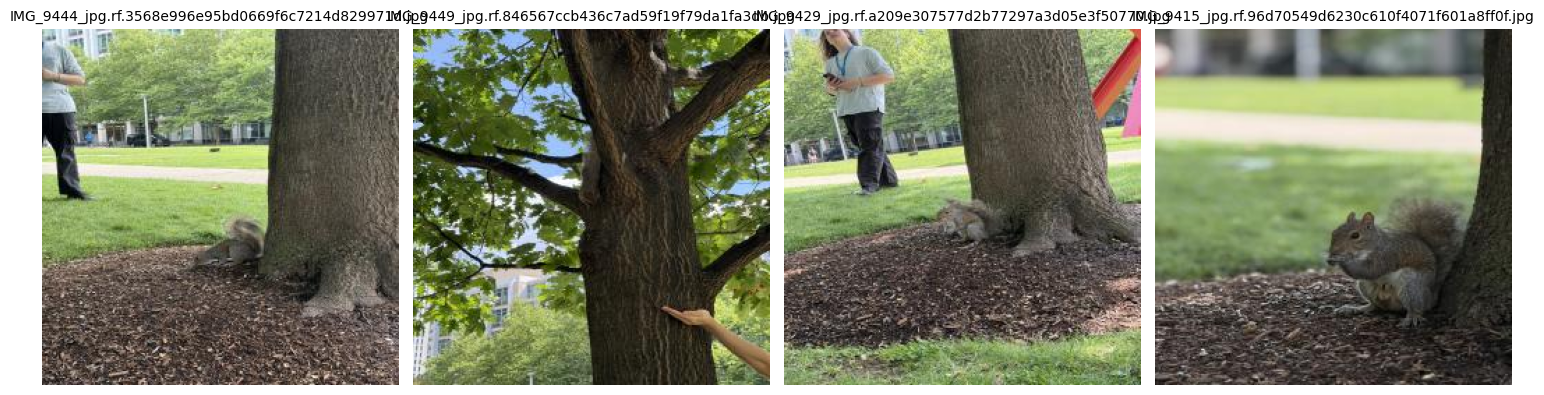

In [40]:
image_files = os.listdir(path_to_dataset + "/train/images/")
print(image_files)

label_files = os.listdir(path_to_dataset + "/train/labels/")
print(label_files)

image_files_view = image_files[:4]
path_to_images = path_to_dataset + "/train/images/"

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, filename in enumerate(image_files_view):
    full_path = os.path.join(path_to_images, filename)
    img = Image.open(full_path)
    axes[i].imshow(img)
    axes[i].set_title(filename, fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# class_id center_x center_y width height

In [41]:
path_to_images = path_to_dataset + "/train/images/"
path_to_labels = path_to_dataset + "/train/labels/"

pairs = []

for img in image_files:
    img_name = os.path.splitext(img)[0]

    for label in label_files:
        label_name = os.path.splitext(label)[0]

        if img_name == label_name:
            pairs.append((img, label))

print(pairs)

[('IMG_9444_jpg.rf.3568e996e95bd0669f6c7214d829971d.jpg', 'IMG_9444_jpg.rf.3568e996e95bd0669f6c7214d829971d.txt'), ('IMG_9449_jpg.rf.846567ccb436c7ad59f19f79da1fa3db.jpg', 'IMG_9449_jpg.rf.846567ccb436c7ad59f19f79da1fa3db.txt'), ('IMG_9429_jpg.rf.a209e307577d2b77297a3d05e3f50770.jpg', 'IMG_9429_jpg.rf.a209e307577d2b77297a3d05e3f50770.txt'), ('IMG_9415_jpg.rf.96d70549d6230c610f4071f601a8ff0f.jpg', 'IMG_9415_jpg.rf.96d70549d6230c610f4071f601a8ff0f.txt'), ('IMG_9433_jpg.rf.4f7f07746e6a75b99e8804846c155de5.jpg', 'IMG_9433_jpg.rf.4f7f07746e6a75b99e8804846c155de5.txt'), ('IMG_9425_jpg.rf.a86fc5ccc46852922ef2f528f116b84a.jpg', 'IMG_9425_jpg.rf.a86fc5ccc46852922ef2f528f116b84a.txt'), ('IMG_9431_jpg.rf.c46a641c2d5fd6252f89759d4367ecdf.jpg', 'IMG_9431_jpg.rf.c46a641c2d5fd6252f89759d4367ecdf.txt'), ('IMG_9422_jpg.rf.a3a6338b04168ba0a88e470653e9d540.jpg', 'IMG_9422_jpg.rf.a3a6338b04168ba0a88e470653e9d540.txt'), ('IMG_9412_jpg.rf.fbda07160c33516335cfbe907599ffc7.jpg', 'IMG_9412_jpg.rf.fbda07160c335

bbox: 0 0.521484375 0.60546875 0.25390625 0.162109375
bbox: 0 0.49609375 0.400390625 0.0859375 0.201171875
bbox: 0 0.51953125 0.537109375 0.197265625 0.158203125
bbox: 0 0.669921875 0.66015625 0.38671875 0.37890625


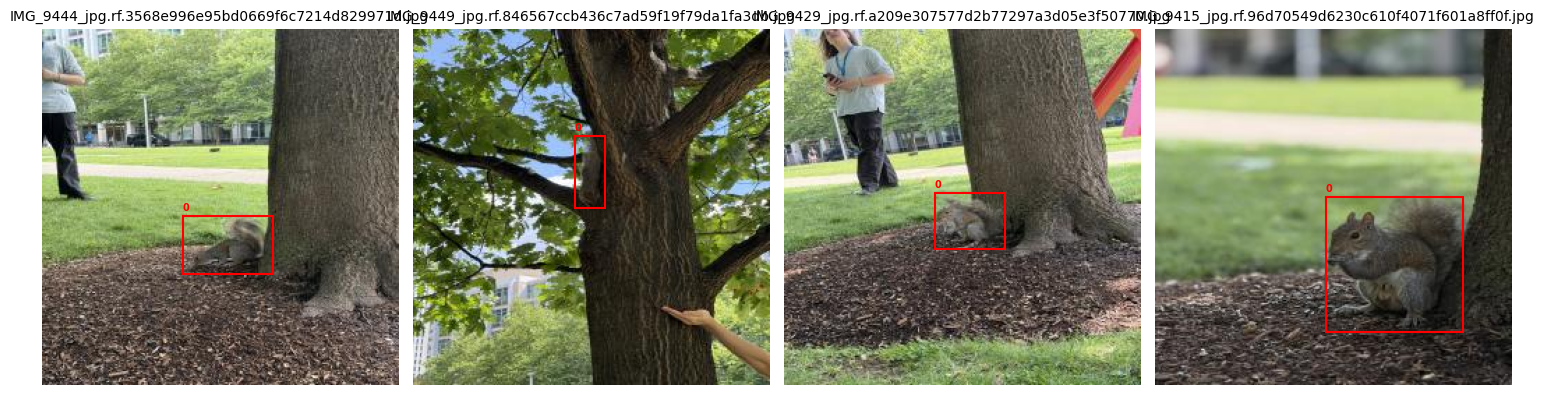

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, pair in enumerate(pairs[:4]):
    img_filename, label_filename = pair

    img_path = os.path.join(path_to_images, img_filename)
    label_path = os.path.join(path_to_labels, label_filename)

    img = Image.open(img_path)
    width, height = img.size

    axes[i].imshow(img)
    axes[i].set_title(img_filename, fontsize=10)
    axes[i].axis("off")

    with open(label_path) as f:
        for line in f:
            print("bbox: " + line)

            parts = line.split()
            class_num = int(parts[0])
            center_x = float(parts[1])
            center_y = float(parts[2])
            b_width = float(parts[3])
            b_height = float(parts[4])

            # Convert YOLO coordinates to pixel coordinates.
            # YOLO coordinates are required by the model.
            # Pixel coordinates are required for visualization.
            x1 = (center_x - b_width / 2) * width
            y1 = (center_y - b_height / 2) * height
            box_w = b_width * width
            box_h = b_height * height

            rect = plt.Rectangle(
                (x1, y1),
                box_w,
                box_h,
                linewidth=1.5,
                edgecolor="red",
                facecolor="none",
            )

            axes[i].add_patch(rect)
            axes[i].text(
                x1,
                y1 - 4,
                str(class_num),
                color="red",
                fontsize=7,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

In [43]:
yaml_file = path_to_dataset + "/data.yaml"

MODEL = "yolo26n.pt"

model = YOLO(MODEL)
model.train(data=str(yaml_file), epochs=50, imgsz=640)
model.val(data=str(yaml_file))

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Squirrel Detection.v4i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ed45f70d070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [55]:
custom_image_path = "/content/drive/MyDrive/squirrel2.jpeg"

model = YOLO("runs/detect/train/weights/best.pt")
results = model.predict(source=custom_image_path, save=True, conf=0.25)


image 1/1 /content/drive/MyDrive/squirrel2.jpeg: 640x384 1 Squirrel, 11.2ms
Speed: 2.4ms preprocess, 11.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict-14


In [64]:
custom_image_path = "/content/drive/MyDrive/sq5.PNG"

model = YOLO("runs/detect/train/weights/best.pt")
results = model.predict(source=custom_image_path, save=True, conf=0.25)


image 1/1 /content/drive/MyDrive/sq5.PNG: 640x320 1 Squirrel, 17.8ms
Speed: 2.6ms preprocess, 17.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 320)
Results saved to /content/runs/detect/predict-18
